In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
HOME = '/content/drive/MyDrive/Colab_Notebooks/Computer Vision course/DL/04 - Segmentation-Tecnun/' # Home directory
path_video = HOME + 'fiesta.mp4'
print("HOME:", HOME)

HOME: /content/drive/MyDrive/Colab_Notebooks/Computer Vision course/DL/04 - Segmentation-Tecnun/


In [ ]:
images_folder = 'TecnunSAM' # folder to save the images from the video, if not exist, will be created

if os.path.exists(os.path.join(HOME,images_folder)):
  print('TecnunSAM exists')
else:
  os.makedirs(HOME+images_folder, exist_ok=True)
  print('TecnunSAM created')

TecnunSAM exists


In [ ]:
# Extracting images from the video

import cv2

rate_selection = 500 # 1 frame selected every 500
video = cv2.VideoCapture(path_video)
cont = 0

while True:
    ret, frame = video.read()
    if not ret:
        break
    if cont%rate_selection == 0:
      cv2.imwrite(os.path.join(HOME,images_folder, str(cont)+'.jpg'), frame)
    cont+=1
video.release()

In [ ]:
files = os.listdir(os.path.join(HOME, images_folder))
images_names = [archivo for archivo in files if archivo.lower().endswith(".jpg")]
images_names

['0.jpg', '500.jpg', '1000.jpg', '1500.jpg', '2000.jpg', '2500.jpg']

## Install SAM

In [ ]:
!pip install -q 'git+https://github.com/facebookresearch/segment-anything.git'

  Preparing metadata (setup.py) ... done


In [ ]:
!pip install -q jupyter_bbox_widget roboflow dataclasses-json supervision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.5/181.5 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.7/213.7 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 727.4/727.4 kB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 57.4 MB/s eta 0:00:00


### Download SAM weights

In [ ]:
import os

os.makedirs(HOME+'weights', exist_ok=True)

CHECKPOINT_PATH = os.path.join(HOME, "weights", "sam_vit_h_4b8939.pth")

if os.path.exists(CHECKPOINT_PATH):
  print('Checkpoint exists')
else:
  !wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth -P '/content/drive/MyDrive/Colab_Notebooks/Computer Vision course/DL/04 - Segmentation-Tecnun/weights'
  print('Checkpoint downloaded')

print(CHECKPOINT_PATH, "; exist:", os.path.isfile(CHECKPOINT_PATH))

Checkpoint downloaded
/content/drive/MyDrive/Colab_Notebooks/Computer Vision course/DL/04 - Segmentation-Tecnun/weights/sam_vit_h_4b8939.pth ; exist: True


## Load Model

In [ ]:
import torch

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
MODEL_TYPE = "vit_h"

In [ ]:
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor

sam = sam_model_registry[MODEL_TYPE](checkpoint=CHECKPOINT_PATH).to(device=DEVICE)

/usr/local/lib/python3.10/dist-packages/segment_anything/build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f)


In [ ]:
mask_generator = SamAutomaticMaskGenerator(sam)

In [ ]:
import os

IMAGES_PATH = []

for image_name in images_names:
  IMAGES_PATH.append(os.path.join(HOME, images_folder, image_name))

### Generate masks with SAM

In [ ]:
import cv2
import supervision as sv

ALL_SAM_RESULTS = []
# these variables are just for visualizing their fields in the next cell
sam_result_cell=None
detections_cell=None

for IMAGE_PATH in IMAGES_PATH:
  image_bgr = cv2.imread(IMAGE_PATH)
  image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

  # generate masks for the image
  sam_result = mask_generator.generate(image_rgb)
  sam_result_cell=sam_result

  ALL_SAM_RESULTS.append(sam_result)
  mask_annotator = sv.MaskAnnotator(color_lookup=sv.ColorLookup.INDEX)

  detections = sv.Detections.from_sam(sam_result=sam_result)
  detections_cell = detections

  annotated_image = mask_annotator.annotate(scene=image_bgr.copy(), detections=detections)

  sv.plot_images_grid(
      images=[image_bgr, annotated_image],
      grid_size=(1, 2),
      titles=['source image', 'segmented image']
  )

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# This variable is a dictionary
# -segmentation: in true-false, each mask
# -area: it is the number of pixels
# -bbox: they are the coordinates or edges of a square that includes the mask
# -point_coords: it is the center of the mask

sam_result_cell

[{'segmentation': array([[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         ...,
         [ True,  True,  True, ..., False, False, False],
         [ True,  True,  True, ..., False, False, False],
         [False, False, False, ..., False, False, False]]),
  'area': 59771,
  'bbox': [0, 491, 448, 227],
  'predicted_iou': 1.0308444499969482,
  'point_coords': [[340.0, 641.25]],
  'stability_score': 0.9861304759979248,
  'crop_box': [0, 0, 1280, 720]},
 {'segmentation': array([[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         ...,
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]]),
  'area': 125393,
  'bbox': [805, 91, 339,

In [ ]:
# This variable is an object
# The previous object (sam_result) is converted to another one, which has a box and a mask
# simple object change, taking only the fields that interest, to use SV's drawing function
# todas las máscaras con sus boxes
detections_cell

Detections(xyxy=array([[   0,    0, 1279,  387],
       [   7,  397, 1209,  718],
       [ 314,  396, 1042,  717],
       [ 805,   91, 1144,  671],
       [   0,  282,  468,  718],
       [ 869,  253, 1145,  668],
       [ 624,   78,  870,  514],
       [   0,  159,  381,  683],
       [   0,  160,  234,  682],
       [   0,  491,  448,  718],
       [ 639,  210,  861,  514],
       [1018,  229, 1279,  551],
       [ 158,  281,  373,  499],
       [ 805,  198, 1052,  625],
       [   0,  316,  160,  608],
       [ 806,   91,  987,  266],
       [1062,  442, 1248,  709],
       [1129,  442, 1248,  709],
       [ 952,  329, 1117,  526],
       [1017,  228, 1279,  358],
       [  32,  236,  387,  578],
       [ 804,  427, 1052,  625],
       [  40,  158,  235,  310],
       [  31,  236,  213,  420],
       [ 166,  416,  475,  718],
       [1136,  357, 1279,  553],
       [ 166,  418,  367,  575],
       [ 375,  287,  633,  401],
       [ 700,   94,  798,  303],
       [ 372,  337,  664,  

In [ ]:
# primera máscara con su box
print(detections_cell[0])

Detections(xyxy=array([[   0,    0, 1279,  387]]), mask=array([[[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]]]), confidence=None, class_id=None, tracker_id=None)


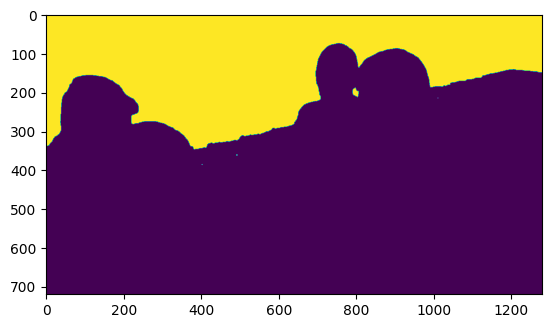

In [ ]:
import matplotlib.pyplot as plt

# comprobar qué máscara es y a qué foto corresponde
plt.imshow(detections_cell[0].mask[0])